## Decision trees

### To-Do's in this file
- actually finish the decision tree model
  - this is done
  - model is overfit though I am pretty sure
- make a random forest model
- add cross-validation for both models
  - added to random forest
- add grid search for hyperparameters
  - might have to have it be a small grid search
- add visualizations
- add ROC curve

In [ ]:
# to keep your computer open for a long time, run this in the terminal
# caffeinate -dims

### Packages

In [2]:
# Data handling
import pandas as pd
import geopandas as gpd
import numpy as np

# Geopandas Dependency
import pyarrow

# Data reading
import requests
from io import BytesIO, StringIO

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import leafmap.foliumap as leafmap
import plotly.express as px


# Model requirements
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


# Model validation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc, precision_score, recall_score


### Read the Clean Datasets

In [2]:
# Read the origin time series file into a DataFrame
url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))

### Displaying the Dataset

In [3]:
display(origin.head())

,month,day_of_week,hour_of_day,origin_station_complex_id,origin_station_complex_name,origin_latitude,origin_longitude,origin_point,sum_estimated_average_ridership
0,1,Friday,0,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),35.7473
1,1,Friday,1,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),11.4975
2,1,Friday,2,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),10.9980
3,1,Friday,3,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),14.7534
4,1,Friday,4,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),52.0023


In [4]:
origin.dtypes

month                                int64
day_of_week                         object
hour_of_day                          int64
origin_station_complex_id            int64
origin_station_complex_name         object
origin_latitude                    float64
origin_longitude                   float64
origin_point                        object
sum_estimated_average_ridership    float64
dtype: object

### Train-Test Split

In [5]:
#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
X = pd.get_dummies(X, drop_first=True) #one_hot encoding here
Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)

In [6]:
from sklearn.preprocessing import OneHotEncoder

#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
#one hot encoding
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, drop = 'first')
one_hot_encoded = encoder.fit_transform(X[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([X, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
X = df_encoded

Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)


display(X)

,month,hour_of_day,origin_latitude,origin_longitude,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,...,"origin_station_complex_name_West Farms Sq-E Tremont Av (2,5)",origin_station_complex_name_Westchester Sq-E Tremont Av (6),origin_station_complex_name_Whitlock Av (6),origin_station_complex_name_Wilson Av (L),"origin_station_complex_name_Winthrop St (2,5)","origin_station_complex_name_Woodhaven Blvd (J,Z)","origin_station_complex_name_Woodhaven Blvd (M,R)",origin_station_complex_name_Woodlawn (4),origin_station_complex_name_York St (F),origin_station_complex_name_Zerega Av (6)
0,1,0,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,3,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,4,40.775036,-73.912034,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852928,12,19,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
852929,12,20,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
852930,12,21,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
852931,12,22,40.692259,-73.986642,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
#train test split happening
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=4)

### Decision Tree Model

In [ ]:
#full model takes a while

In [8]:
ridership_tree = (
    DecisionTreeRegressor(random_state = 3870)
    .fit(X = X_train, y = y_train)
)

In [9]:
R2_train = ridership_tree.score(X_train, y_train)
R2_test = ridership_tree.score(X_test, y_test)

print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')

R-squared for the training set is: 1.00 and the R-squared of the test set is  0.99


### Pruning the Tree (OLD VERSION TOOK TOO LONG to run)

In [ ]:
#line below takes a long time

In [46]:
# ridership_ccp_alphas = (
#     ridership_tree       # model
#     .cost_complexity_pruning_path(X_train, y_train) # Finding the results for each split point
#     .ccp_alphas # Getting just the ccp_alphas
# )

# # How many splits are there?
# ridership_ccp_alphas.size

495820

In [47]:
# display(ridership_ccp_alphas)

array([0.00000000e+00, 1.38843178e-21, 1.38843178e-21, ...,
       2.34330642e+04, 3.00634049e+04, 5.27537705e+04], shape=(495820,))

In [68]:
#making a smaller ridership_ccp_alphas
#this is for pure time concerns, i just don't feel like waiting that long
# ridership_ccp_alphas_small = []
# i = 1
# while i < (len(ridership_ccp_alphas)):
#     ridership_ccp_alphas_small.append(ridership_ccp_alphas[i])
#     i = i + 5000

# ridership_ccp_alphas_small = np.array(ridership_ccp_alphas_small)
# display(ridership_ccp_alphas_small)
# print(len(ridership_ccp_alphas_small))

array([1.38843178e-21, 7.43025235e-09, 3.22731785e-08, 4.95964586e-08,
       1.22446369e-07, 1.93766451e-07, 2.38315458e-07, 3.75051402e-07,
       4.43066513e-07, 6.22602388e-07, 7.81030339e-07, 9.45069603e-07,
       1.19987760e-06, 1.37825238e-06, 1.69455481e-06, 1.96918151e-06,
       2.34582984e-06, 2.66757237e-06, 3.12459482e-06, 3.59356013e-06,
       4.04854003e-06, 4.70045450e-06, 5.28429003e-06, 5.95248609e-06,
       6.83111095e-06, 7.67505417e-06, 8.56734419e-06, 9.60219181e-06,
       1.08970157e-05, 1.21436240e-05, 1.35198593e-05, 1.50777738e-05,
       1.66949414e-05, 1.85298487e-05, 2.05560569e-05, 2.28077707e-05,
       2.51902293e-05, 2.79528714e-05, 3.06865023e-05, 3.39668351e-05,
       3.75601771e-05, 4.12062678e-05, 4.54047331e-05, 5.00235267e-05,
       5.51273046e-05, 6.05376243e-05, 6.66792020e-05, 7.33393514e-05,
       8.03279126e-05, 8.81639846e-05, 9.68840220e-05, 1.06227258e-04,
       1.16521031e-04, 1.27608187e-04, 1.40038654e-04, 1.53452715e-04,
      

100


In [ ]:
#note, this did not work, the code below took way too long to run (8+hours and was not done)

In [ ]:
# # Importing KFold and cross_val_score
# from sklearn.model_selection import KFold, cross_val_score

# cv10 = KFold(n_splits = 10, shuffle = True, random_state = 3870)

# # List to store the R2 values
# R2_train = []
# R2_cv = []

# # Looping through the different choices of ccp_alpha to create each tree
# i = 0
# for alpha in ridership_ccp_alphas_small:
#     # Calculating the R2 for the full training data
#     R2_train_loop = (
#         DecisionTreeRegressor(random_state = 3870, ccp_alpha=alpha)
#         .fit(X_train, y_train)
#         .score(X_train, y_train)
#     )
#     R2_train.append(R2_train_loop)

#     # Next, R2 using 10-fold CV
#     R2_cv_loop = (
#         cross_val_score(
#             estimator = DecisionTreeRegressor(random_state = 3870, ccp_alpha=alpha), # The model
#             X = X_train,
#             y = y_train,
#             cv = cv10,
#             scoring = 'r2',
#             n_jobs = -1 # Using all processor cores
#         )
#     ).mean()
#     R2_cv.append(R2_cv_loop)
#     i = i + 1
#     print(f"this is alpha number {i}")

this is alpha number 1
this is alpha number 2
this is alpha number 3
this is alpha number 4
this is alpha number 5
this is alpha number 6
this is alpha number 7
this is alpha number 8
this is alpha number 9
this is alpha number 10
this is alpha number 11
this is alpha number 12
this is alpha number 13
this is alpha number 14
this is alpha number 15
this is alpha number 16
this is alpha number 17
this is alpha number 18
this is alpha number 19
this is alpha number 20
this is alpha number 21
this is alpha number 22
this is alpha number 23
this is alpha number 24
this is alpha number 25


In [ ]:
# # Data set for the different choices of alpha, training accuracy, and testing accuracy
# pruning_df = pd.DataFrame({
#     'alpha': ridership_ccp_alphas_small,  # Different choices of alpha
#     'train': R2_train,        # Training accuracy 
#     'cross-validation':  R2_cv            # Cross-val accuray
# }).melt(id_vars = 'alpha', value_name = 'R-squared', var_name = 'set') # Stacking the train and test accuracy columns together


# # Line graph to show how the accuracy changes
# sns.lineplot(
#     data = pruning_df,
#     x = 'alpha',
#     y = 'R-squared',
#     hue = 'set'
# );

In [ ]:
# best_alpha = (
#   pruning_df
#  .query('set == "cross-validation"') # Just looking at the accuracy of the test set
#  .nlargest(columns = 'R-squared', n = 1) # Picking the row with the highest accuracy
# )

# best_alpha

In [ ]:
# #final pruned tree
# ridership_tree_pruned = (
#     DecisionTreeRegressor(
#         ccp_alpha = best_alpha['alpha'].sum(),  # sum converts it from a series to a float
#         random_state = 3870
#     )
#     .fit(X = X_train, y = y_train)
# )

In [ ]:
#r squared vals
# ridership_tree_pruned.score(X_test, y_test)

In [ ]:
# # code from: https://scikit-learn.org/1.4/model_persistence.html#:~:text=9.-,Model%20persistence
# #for more, consider this website: https://wandb.ai/a-sh0ts/publications/reports/How-to-Save-a-Classifier-to-Disk-in-Scikit-learn--Vmlldzo0NDc1ODI0
# #saving the model
# import pickle

# with open('pruned_tree.pkl', 'wb') as f:
#     pickle.dump(ridership_tree_pruned, f)

# #to read the file
# # with open('pruned_tree.pkl', 'rb') as f:
# #    pickle.load(ridership_tree_pruned, f)
# #

### Pruning the tree take 2

some notes
- need to add constraints, model was taking, way, way to long to run if I do not
- i am sure my previous code chunk had mistakes, but i left it to run for 10 hours and it did not finish, sooooo, I decided to move on to another less computationally expensive method that should work about as well
- the one below takes a lot less time
  - still takes like 20 minutes though

In [17]:
from sklearn.model_selection import GridSearchCV


param_grid = {'max_depth':range(1, 200, 3)}
cross_val_tree = DecisionTreeRegressor()
search = GridSearchCV(cross_val_tree, param_grid, cv=5, scoring = 'r2')
grid_search = search.fit(X_train, y_train)


Text(0, 0.5, 'Val Accuracy')

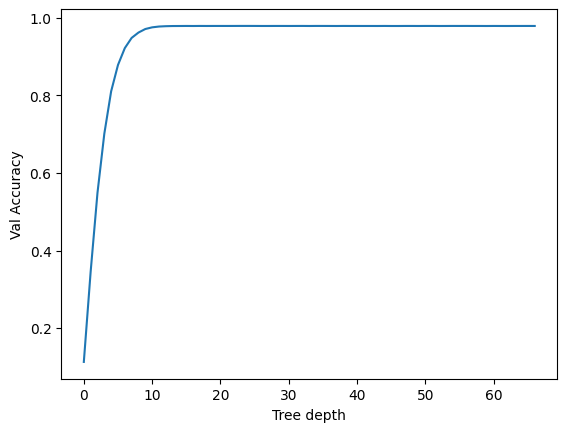

In [18]:
plt.plot(search.cv_results_['mean_test_score'])
plt.xlabel('Tree depth')
plt.ylabel('Val Accuracy')

In [24]:
depth = grid_search.best_params_['max_depth']
print(depth)
ridership_tree_pruned = DecisionTreeRegressor(max_depth=depth).fit(X_train, y_train)
R2_train = ridership_tree_pruned.score(X_train, y_train)
R2_test = ridership_tree_pruned.score(X_test, y_test)

print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')

73
R-squared for the training set is: 1.00 and the R-squared of the test set is  0.99


In [25]:
# code from: https://scikit-learn.org/1.4/model_persistence.html#:~:text=9.-,Model%20persistence
#for more, consider this website: https://wandb.ai/a-sh0ts/publications/reports/How-to-Save-a-Classifier-to-Disk-in-Scikit-learn--Vmlldzo0NDc1ODI0
#saving the model
import pickle

with open('pruned_tree.pkl', 'wb') as f:
    pickle.dump(ridership_tree_pruned, f)

#to read the file
# with open('pruned_tree.pkl', 'rb') as f:
#    ridership_tree_pruned = pickle.load(f)
#

### Feature importance


In [26]:
feat_import_pruned = ridership_tree_pruned.feature_importances_
feat_import_full = ridership_tree.feature_importances_

feat_import_df = pd.DataFrame({
        'feature': X_train.columns,
        'full': feat_import_full,
        'pruned': feat_import_pruned
    }).sort_values(by = 'pruned').reset_index().drop(columns = 'index', axis = 1)

In [27]:
feat_import_df

,feature,full,pruned
0,origin_station_complex_name_Beach 36 St (A),9.959052e-09,6.799157e-09
1,origin_station_complex_name_Beach 44 St (A),8.482758e-09,1.023535e-08
2,origin_station_complex_name_Neptune Av (F),2.589623e-08,1.719308e-08
3,origin_station_complex_name_Avenue N (F),2.734641e-08,3.264335e-08
4,origin_station_complex_name_Avenue P (F),4.191795e-08,3.881893e-08
...,...,...,...
428,origin_station_complex_name_Grand Central-42 S...,6.423496e-02,6.423498e-02
429,origin_longitude,8.279595e-02,8.296591e-02
430,origin_latitude,1.175492e-01,9.667989e-02
431,"origin_station_complex_name_Times Sq-42 St (N,...",1.127163e-01,1.127163e-01


In [29]:
feat_import_df = feat_import_df[feat_import_df['full'] >= .01]
feat_import_df = feat_import_df[feat_import_df['pruned'] >= .01]
feat_import_df

,feature,full,pruned
418,origin_station_complex_name_34 St-Penn Station...,0.010007,0.010007
419,origin_station_complex_name_59 St-Columbus Cir...,0.010748,0.010748
420,origin_station_complex_name_Flushing-Main St (7),0.013404,0.013404
421,origin_station_complex_name_74-Broadway (7)/Ja...,0.013571,0.013571
422,month,0.015041,0.015042
424,"origin_station_complex_name_Fulton St (A,C,J,Z...",0.020661,0.020661
425,origin_station_complex_name_34 St-Herald Sq (B...,0.021675,0.021675
426,day_of_week_Saturday,0.033909,0.033909
427,day_of_week_Sunday,0.036195,0.036195
428,origin_station_complex_name_Grand Central-42 S...,0.064235,0.064235


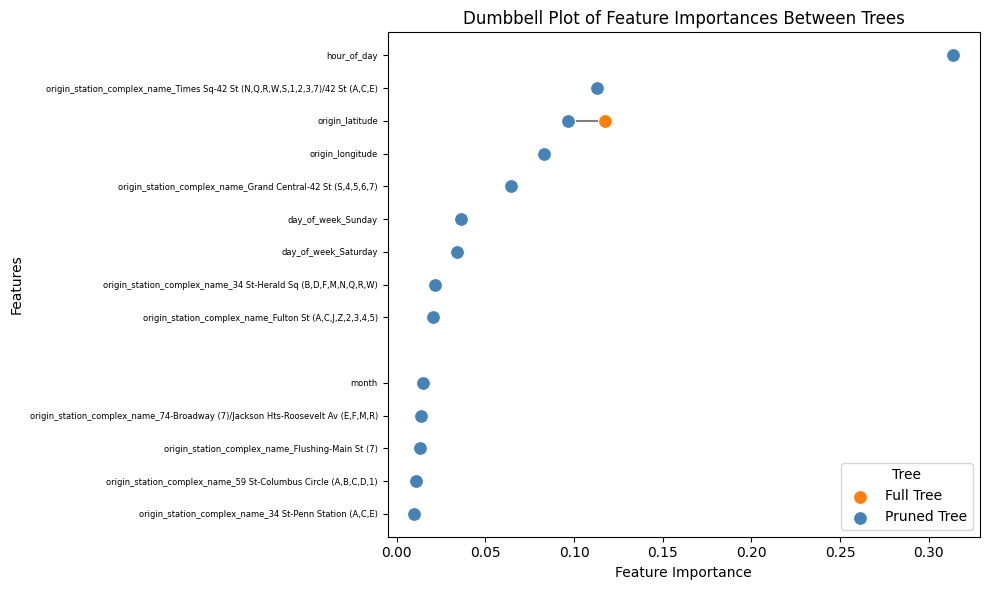

In [36]:
# Point for the full tree
# sns.set_theme(font_scale=1.5)  # Increases all text by 50%
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x = feat_import_df['full'],
    y = feat_import_df.index,
    color = '#FF7F0E',
    s = 100, 
    label = 'Full Tree',
    zorder = 2
)

# Points for the pruned tree
sns.scatterplot(
    x = feat_import_df['pruned'],
    y = feat_import_df.index,
    color = 'steelblue',
    s = 100, 
    label = 'Pruned Tree',
    zorder = 2
)

# Adding the lines
for i, row in feat_import_df.iterrows():
    plt.plot(
        [row['full'], row['pruned']], 
        [i,i], 
        color = 'grey',
        zorder = 1
    )

plt.title("Dumbbell Plot of Feature Importances Between Trees")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.yticks(feat_import_df.index, feat_import_df['feature'], fontsize = 6)
plt.legend(title='Tree', loc='lower right')
plt.tight_layout()

## Decision Tree Without Stations

The impetus for this is that the tree appears to be quite overfit. This could be because of the vast number of stations, where the stations allow for a lot of mini-trees within the larger tree that can super easily target each ridership value. To see if this is needed, I will just be removing the stations from the dataset

In [12]:
from sklearn.preprocessing import OneHotEncoder

url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))
#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
X = X.drop('origin_station_complex_name', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis

Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)

#one hot encoding
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, drop = 'first')
one_hot_encoded = encoder.fit_transform(X[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([X, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
X = df_encoded

# print(X)

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=4)

In [26]:
small_ridership_tree = (
    DecisionTreeRegressor(random_state = 3870)
    .fit(X = X_train, y = y_train)
)
R2_train = small_ridership_tree.score(X_train, y_train)
R2_test = small_ridership_tree.score(X_test, y_test)

# print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')
print(f'R-squared for the training set is: {np.sqrt(R2_train)} and the R-squared of the test set is {np.sqrt(R2_test)}')

R-squared for the training set is: 1.0 and the R-squared of the test set is 0.9911408130727509


In [15]:
from sklearn.model_selection import GridSearchCV

#aiming for a smaller tree
param_grid = {'max_depth':range(1, 30, 1)}
cross_val_tree = DecisionTreeRegressor()
search = GridSearchCV(cross_val_tree, param_grid, cv=5, scoring = 'r2')
grid_search = search.fit(X_train, y_train)

Text(0, 0.5, 'Val Accuracy')

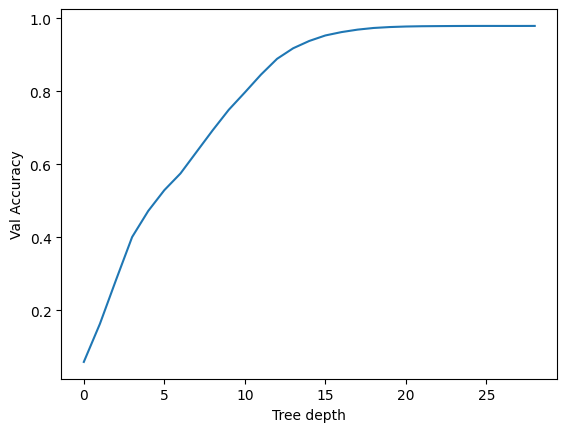

In [16]:
plt.plot(search.cv_results_['mean_test_score'])
plt.xlabel('Tree depth')
plt.ylabel('Val Accuracy')

In [25]:
depth = grid_search.best_params_['max_depth']
print(depth)
small_ridership_tree_pruned = DecisionTreeRegressor(max_depth=depth).fit(X_train, y_train)
R2_train = small_ridership_tree_pruned.score(X_train, y_train)
R2_test = small_ridership_tree_pruned.score(X_test, y_test)

# print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')
print(f'R-squared for the training set is: {np.sqrt(R2_train)} and the R-squared of the test set is {np.sqrt(R2_test)}')

29
R-squared for the training set is:0.9999541808763431 and the R-squared of the test set is 0.9911931629209159


In [18]:
import pickle

with open('small_pruned_tree.pkl', 'wb') as f:
    pickle.dump(small_ridership_tree_pruned, f)

In [22]:
feat_import_pruned = small_ridership_tree_pruned.feature_importances_
feat_import_full = small_ridership_tree.feature_importances_

feat_import_df = pd.DataFrame({
        'feature': X_train.columns,
        'full': feat_import_full,
        'pruned': feat_import_pruned
    }).sort_values(by = 'pruned').reset_index().drop(columns = 'index', axis = 1)

In [23]:
feat_import_df = feat_import_df[feat_import_df['full'] >= .01]
feat_import_df = feat_import_df[feat_import_df['pruned'] >= .01]

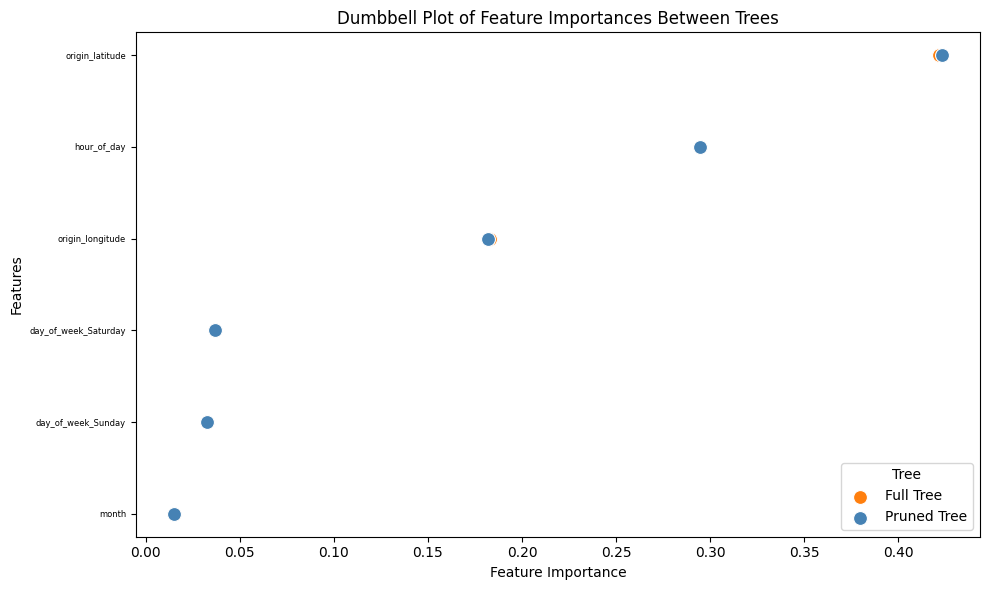

In [24]:
# Point for the full tree
# sns.set_theme(font_scale=1.5)  # Increases all text by 50%
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x = feat_import_df['full'],
    y = feat_import_df.index,
    color = '#FF7F0E',
    s = 100, 
    label = 'Full Tree',
    zorder = 2
)

# Points for the pruned tree
sns.scatterplot(
    x = feat_import_df['pruned'],
    y = feat_import_df.index,
    color = 'steelblue',
    s = 100, 
    label = 'Pruned Tree',
    zorder = 2
)

# Adding the lines
for i, row in feat_import_df.iterrows():
    plt.plot(
        [row['full'], row['pruned']], 
        [i,i], 
        color = 'grey',
        zorder = 1
    )

plt.title("Dumbbell Plot of Feature Importances Between Trees")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.yticks(feat_import_df.index, feat_import_df['feature'], fontsize = 6)
plt.legend(title='Tree', loc='lower right')
plt.tight_layout()

### Interperation

I would go with the smaller tree. it appears a lot of the station differences are covered by longitude and latitude, and other than that they are similar in terms of performance

In [ ]:
There are a few more things to test though
- how they do on outliers (by station)
- 